# AICE1006 - Exploratory Data Analysis (EDA) Coursework
## Dataset: Playstation Sales and Metadata (PS3/PS4/PS5)

## 1. Introduction

This notebook analyses the PlayStation Sales and Metadata dataset across PS3, PS4, and PS5. 
The main aim is to investigate the factors associated with game sales performance, while also 
examining important data-quality issues such as missing metadata and incomplete sales records.

## Setup 1 - Importing Libraries 

In [60]:
# Imports
import numpy as np
import pandas as pd

# Comparsion between matplotlib and plotly will be looked upon throughout...
import matplotlib.pyplot as plt
import plotly.express as px

## Setup 2 - Loading the Dataset

In [61]:
df = pd.read_csv("PlayStation Sales and Metadata (PS3PS4PS5) (Oct 2025).csv")
print(f"Dataset has been loaded and fits the requirmemnts for no. rows ({df.shape[0]}), and no. columns ({df.shape[1]})\n") 
df.head()

Dataset has been loaded and fits the requirmemnts for no. rows (4963), and no. columns (18)



,Game,Console,Name,Publisher,Developer,Total Shipped,Total Sales,NA Sales,PAL Sales,Japan Sales,Other Sales,Release Date,Last Update,rating,ratings_count,metacritic,genres,platforms
0,PS3_Grand Theft Auto V,PS3,Grand Theft Auto V,Rockstar Games,Rockstar North,0,20320000,6370000,9850000,990000,3120000,17/09/2013,NaN,4.47,7225.0,92.0,Action,"PC, PlayStation 5, Xbox One, PlayStation 4, Xb..."
1,PS4_Grand Theft Auto V,PS4,Grand Theft Auto V,Rockstar Games,Rockstar North,0,19390000,6060000,9710000,600000,3020000,18/11/2014,03/01/2018,4.47,7225.0,92.0,Action,"PC, PlayStation 5, Xbox One, PlayStation 4, Xb..."
2,PS4_Call of Duty: Black Ops 3,PS4,Call of Duty: Black Ops 3,Activision,Treyarch,0,15090000,6180000,6050000,410000,2440000,06/11/2015,14/01/2018,NaN,NaN,NaN,NaN,NaN
3,PS4_Red Dead Redemption 2,PS4,Red Dead Redemption 2,Rockstar Games,Rockstar Games,0,13940000,5260000,6210000,210000,2260000,26/10/2018,02/11/2018,4.59,5357.0,96.0,Action,"PC, Xbox One, PlayStation 4"
4,PS3_Call of Duty: Black Ops II,PS3,Call of Duty: Black Ops II,Activision,Treyarch,0,13800000,4990000,5880000,650000,2280000,13/11/2012,NaN,3.96,1417.0,74.0,"Shooter, Action","PC, Xbox One, Xbox 360, PlayStation 3, Wii U"


In [5]:
# Viewing random rows of the df, ensures accuracy through cross-refrecing with Excel
# Ensures no inconsistencies with the dataset on jupyter notebook
df.sample(5)

,Game,Console,Name,Publisher,Developer,Total Shipped,Total Sales,NA Sales,PAL Sales,Japan Sales,Other Sales,Release Date,Last Update,rating,ratings_count,metacritic,genres,platforms
2308,PS5_Sea of Stars,PS5,Sea of Stars,Unknown,Sabotage Studio,0,0,0,0,0,0,NaN,10/04/2023,4.30,120.0,90.0,RPG,"PC, PlayStation 5, Xbox One, PlayStation 4, Xb..."
2609,PS4_Stealth Inc.,PS4,Stealth Inc.,Good Shepherd Entertainment,Unknown,0,0,0,0,0,0,19/03/2014,NaN,NaN,NaN,NaN,NaN,NaN
2905,PS5_Death end re;Quest: Code Z,PS5,Death end re;Quest: Code Z,Unknown,Compile Heart,0,0,0,0,0,0,NaN,08/04/2025,NaN,NaN,NaN,NaN,NaN
2463,PS5_The Case of the Golden Idol: The Spider of...,PS5,The Case of the Golden Idol: The Spider of Lanka,Unknown,Color Gray Games,0,0,0,0,0,0,NaN,29/07/2024,NaN,NaN,NaN,NaN,NaN
3398,PS5_Alan Wake 2: Night Springs,PS5,Alan Wake 2: Night Springs,Unknown,Remedy Entertainment,0,0,0,0,0,0,NaN,09/06/2024,4.04,48.0,NaN,Action,"PC, PlayStation 5, Xbox Series S/X"


## 2. Data Processing

### 2.1 Initial Data Inspection

In [13]:
# Viewing structure and data types of the df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4963 entries, 0 to 4962
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Game           4963 non-null   str    
 1   Console        4963 non-null   str    
 2   Name           4963 non-null   str    
 3   Publisher      4963 non-null   str    
 4   Developer      4963 non-null   str    
 5   Total Shipped  4963 non-null   int64  
 6   Total Sales    4963 non-null   int64  
 7   NA Sales       4963 non-null   int64  
 8   PAL Sales      4963 non-null   int64  
 9   Japan Sales    4963 non-null   int64  
 10  Other Sales    4963 non-null   int64  
 11  Release Date   3526 non-null   str    
 12  Last Update    2801 non-null   str    
 13  rating         2847 non-null   float64
 14  ratings_count  2847 non-null   float64
 15  metacritic     1530 non-null   float64
 16  genres         2803 non-null   str    
 17  platforms      2847 non-null   str    
dtypes: float64(3), int6

In [14]:
# Looking at basic statistics of the df
df.describe() # Source: https://www.geeksforgeeks.org/pandas/python-pandas-dataframe-describe-method/Source: 

,Total Shipped,Total Sales,NA Sales,PAL Sales,Japan Sales,Other Sales,rating,ratings_count,metacritic
count,4.963000e+03,4.963000e+03,4.963000e+03,4.963000e+03,4.963000e+03,4.963000e+03,2847.000000,2847.000000,1530.000000
mean,9.352005e+04,3.008906e+05,1.178199e+05,1.170482e+05,2.178723e+04,4.426154e+04,2.762455,269.917106,73.826144
std,8.977504e+05,1.055158e+06,4.052999e+05,4.946509e+05,8.250273e+04,1.639967e+05,1.531923,618.110338,11.532527
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,21.000000
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.400000,8.000000,68.000000
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.380000,44.000000,76.000000
75%,0.000000e+00,1.600000e+05,7.000000e+04,3.000000e+04,0.000000e+00,2.000000e+04,3.830000,205.500000,82.000000
max,2.269000e+07,2.032000e+07,6.370000e+06,9.850000e+06,2.170000e+06,3.120000e+06,4.760000,7225.000000,97.000000


### 2.2 Missing Data Analysis

In [18]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1) # 1 d.p.

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": missing_pct
}).query("`Missing Values` > 0") # Source (.query): https://note.nkmk.me/en/python-pandas-query/

print(missing_summary)

               Missing Values  Percentage (%)
Release Date             1437            29.0
Last Update              2162            43.6
rating                   2116            42.6
ratings_count            2116            42.6
metacritic               3433            69.2
genres                   2160            43.5
platforms                2116            42.6


### 2.3 Missing Data Mechanism (MCAR Test)

In [68]:
# How the test works: https://medium.com/@tarangds/understanding-littles-mcar-test-a-key-tool-in-missing-data-analysis-47fd70698149
from pyampute.exploration.mcar_statistical_tests import MCARTest # https://rianneschouten.github.io/pyampute/build/html/pyampute.exploration.html

# Only numeric columns can be used in Little's MCAR test
cols_numeric_missing = [
    'rating', 'ratings_count', 'metacritic'
]

mcar_test = MCARTest(method='little')
result = mcar_test.little_mcar_test(df[cols_numeric_missing])

print(f"Little's MCAR Test p-value: {result}")

if result > 0.05:
    print("Result: Data is MCAR (Missing Completely At Random)")
else:
    print("Result: Data is NOT MCAR — missingness is systematic")

Little's MCAR Test p-value: nan
Result: Data is NOT MCAR — missingness is systematic


### 2.4 Distribution of Key Numerical Variables (i.e. Total Sales)

#### Matplotlib

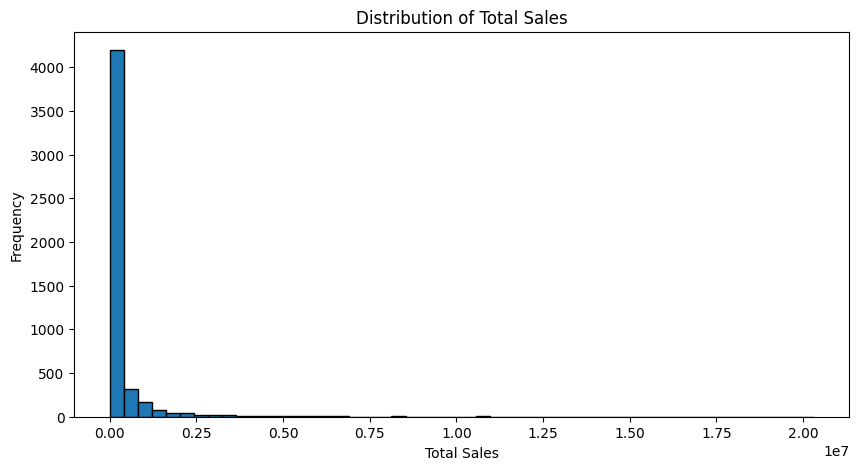

In [4]:
plt.figure(figsize=(10, 5))
plt.hist(df['Total Sales'].dropna(), bins=50, edgecolor='black')
plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.show()

#### Pyplot

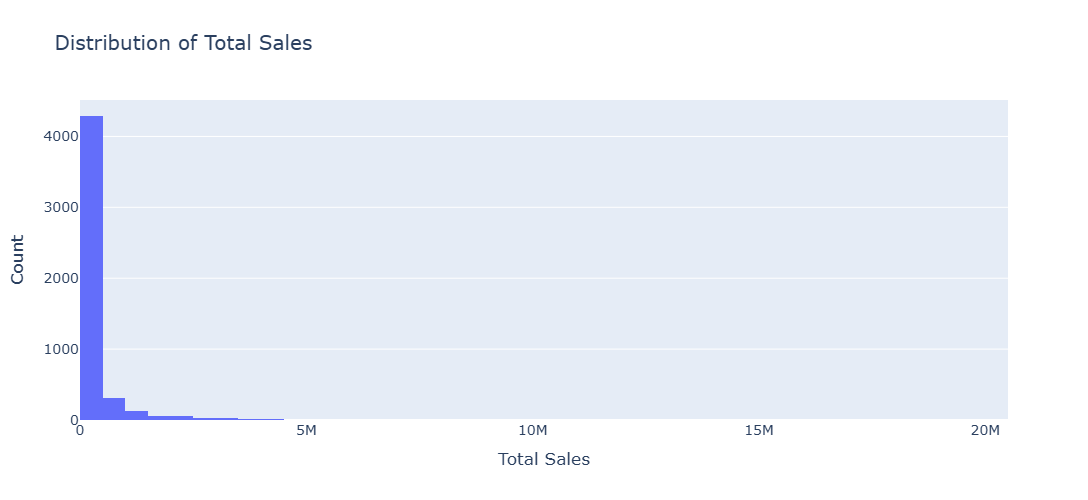

In [36]:
fig = px.histogram(
    df,
    x='Total Sales',
    nbins=50,
    title='Distribution of Total Sales',
    width=1000,
    height=500
)
# .update_layout: https://stackoverflow.com/questions/61980632/update-layout-argument-list-with-plotly
fig.update_layout(
    xaxis_title='Total Sales',
    yaxis_title='Count',
    font_size=14
)

fig.show()

### 2.5 Log Transformation

#### Matplotlib

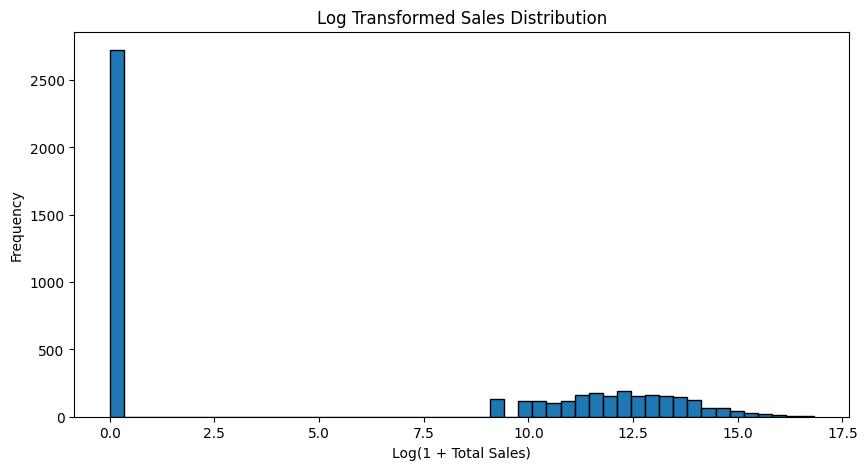

In [5]:
df["Log_Sales"] = np.log1p(df["Total Sales"]) # np.log1p: https://numpy.org/doc/stable/reference/generated/numpy.log1p.html

plt.figure(figsize=(10, 5))
plt.hist(df["Log_Sales"].dropna(), bins=50, edgecolor="black")
plt.title("Log Transformed Sales Distribution")
plt.xlabel("Log(1 + Total Sales)")
plt.ylabel("Frequency")
plt.show()

#### Plotly

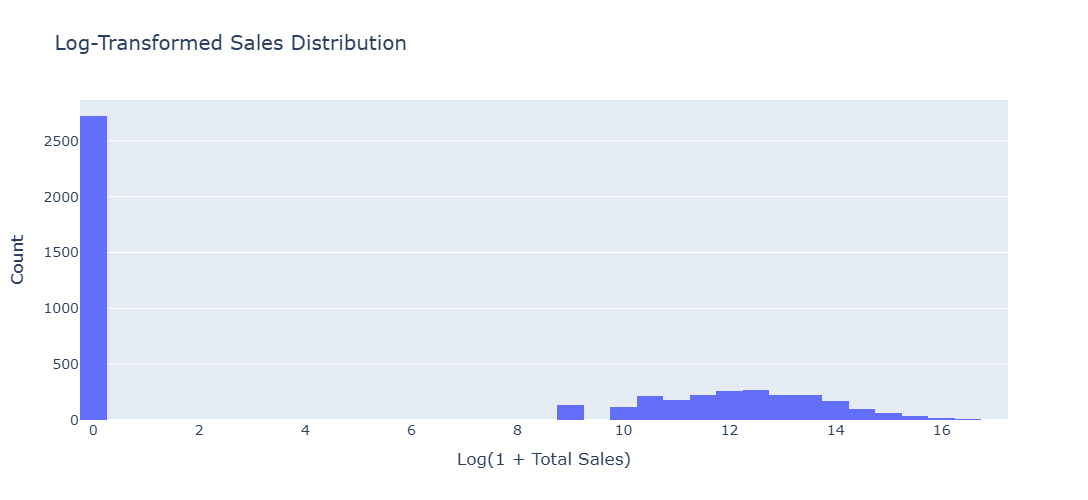

In [6]:
df["Log_Sales"] = np.log1p(df["Total Sales"])

fig = px.histogram(
    df,
    x="Log_Sales",
    nbins=50,
    title="Log-Transformed Sales Distribution",
    width=1000,
    height=500
)

fig.update_layout(
    xaxis_title="Log(1 + Total Sales)",
    yaxis_title="Count",
    font_size=14
)

fig.show()

### 2.6 Systematic error of missing game data
Detecting the root cause for the missing sales data

In [63]:
zero_sales = df['Total Sales'] == 0
result = zero_sales.groupby(df['Console']).mean()
result

Console
PS3    0.309725
PS4    0.530889
PS5    1.000000
Name: Total Sales, dtype: float64

### 2.7 Console-Specific Missing Sales Trends

After identifying PS5 as having entirely missing sales data, the next step is 
to investigate whether the zero-sales issue for PS3 and PS4 also follows a pattern. 
This is examined over release year to determine whether more recent titles are 
more likely to have incomplete sales records.

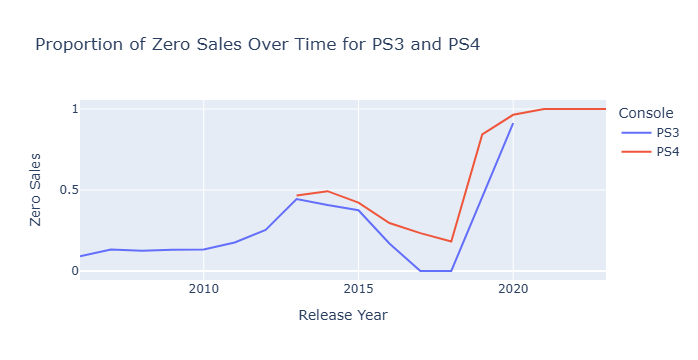

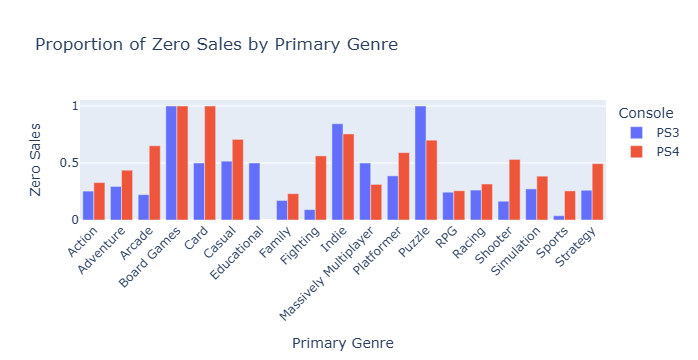

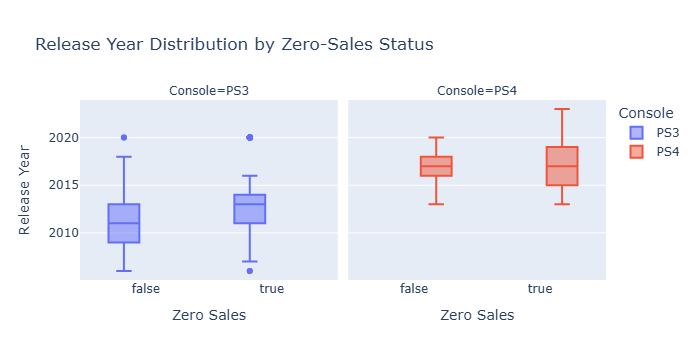

In [16]:
# Keep only PS3 and PS4 for this comparison
df_ps = df[df['Console'].isin(['PS3', 'PS4'])].copy()

# Create Primary Genre if not already done
df_ps['Primary Genre'] = df_ps['genres'].str.split(',').str[0].str.strip()

# 1. Missingness by Release Year and Console
yearly_zero = (
    df_ps.groupby(['Console', 'Release Year'])['Zero Sales']
    .mean()
    .reset_index()
)

fig = px.line(
    yearly_zero,
    x='Release Year',
    y='Zero Sales',
    color='Console',
    title='Proportion of Zero Sales Over Time for PS3 and PS4'
)
fig.show()

# 2. Missingness by Primary Genre and Console
genre_zero = (
    df_ps.groupby(['Console', 'Primary Genre'])['Zero Sales']
    .mean()
    .reset_index()
)

fig2 = px.bar(
    genre_zero,
    x='Primary Genre',
    y='Zero Sales',
    color='Console',
    barmode='group',
    title='Proportion of Zero Sales by Primary Genre'
)
fig2.update_layout(xaxis_tickangle=-45)
fig2.show()

# 3. Faceted sales distribution by zero-sales status
fig3 = px.box(
    df_ps,
    x='Zero Sales',
    y='Release Year',
    color='Console',
    facet_col='Console',
    title='Release Year Distribution by Zero-Sales Status'
)
fig3.show()

### 2.8 Data Cleaning
We handle missing values through imputation and encode categorical 
columns to prepare the dataset for deeper analysis.

In [24]:
from sklearn.impute import SimpleImputer # For Numerical and Categroical Data: https://www.bing.com/ck/a?!&&p=113e0fbf0637431cd243ab9ed9500c708142cf86c07724569e534345447f347bJmltdHM9MTc3NjAzODQwMA&ptn=3&ver=2&hsh=4&fclid=223b16ea-9ba5-60a5-116f-009f9aa26118&psq=numerical+vs+categorical+data&u=a1aHR0cHM6Ly93d3cucXVlc3Rpb25wcm8uY29tL2Jsb2cvY2F0ZWdvcmljYWwtZGF0YS12cy1udW1lcmljYWwtZGF0YS8

# Numerical Imputation with mean
num_data = df[["rating", "ratings_count", "metacritic"]]
mean_imp = SimpleImputer(strategy="mean") # https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html
df[["rating", "ratings_count", "metacritic"]] = mean_imp.fit_transform(num_data) # .fit_transform source: https://www.educative.io/answers/the-fit-vs-fittransform-methods-in-scikit-learn

# Categorical imputation using mode
cat_data = df[["genres", "Release Date", "Last Update", "platforms"]]
mode_imp = SimpleImputer(strategy="most_frequent") # https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html
df[["genres", "Release Date", "Last Update", "platforms"]] = mode_imp.fit_transform(cat_data)

# Double checking no. missing values remain: https://www.geeksforgeeks.org/python/count-nan-or-missing-values-in-pandas-dataframe/
print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


## 3. Data Visualization

### 3.1 Descriptive Statistics and Console-Level Analysis

#### 3.1.1 Descriptive Statistics

In [8]:
# Overall descriptive statistics for the key numerical columns
key_cols = ["Total Sales", "NA Sales", "PAL Sales", "Japan Sales", "Other Sales", "rating", "ratings_count", "metacritic"]

df[key_cols].describe().round(2)

,Total Sales,NA Sales,PAL Sales,Japan Sales,Other Sales,rating,ratings_count,metacritic
count,4963.00,4963.00,4963.00,4963.00,4963.00,2847.00,2847.00,1530.00
mean,300890.59,117819.87,117048.16,21787.23,44261.54,2.76,269.92,73.83
std,1055157.89,405299.89,494650.92,82502.73,163996.69,1.53,618.11,11.53
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,21.00
25%,0.00,0.00,0.00,0.00,0.00,2.40,8.00,68.00
50%,0.00,0.00,0.00,0.00,0.00,3.38,44.00,76.00
75%,160000.00,70000.00,30000.00,0.00,20000.00,3.83,205.50,82.00
max,20320000.00,6370000.00,9850000.00,2170000.00,3120000.00,4.76,7225.00,97.00


#### 3.1.2 Group by console and compute mean statistics

In [9]:
console_stats = df.groupby("Console")[key_cols].mean().round(2) # https://www.geeksforgeeks.org/pandas/python-pandas-dataframe-groupby/
console_stats

,Total Sales,NA Sales,PAL Sales,Japan Sales,Other Sales,rating,ratings_count,metacritic
Console,,,,,,,,
PS3,443794.93,185570.82,159714.59,35771.67,62854.12,2.59,266.36,73.10
PS4,328307.38,117348.07,139994.98,20316.42,50602.71,2.83,321.12,74.18
PS5,0.00,0.00,0.00,0.00,0.00,2.98,143.54,75.23


#### 3.1.3 Count of games per console

In [10]:
df["Console"].value_counts()

Console
PS4    1991
PS3    1892
PS5    1080
Name: count, dtype: int64

This was useful because it gave some context for the rest of the comparisons, especially when looking at sales totals and genre counts across platform. The game-count comparison shows that PS4 has the largest number of titles in the dataset, followed closely by PS3, while PS5 contains substantially fewer entries. This gives useful context for later comparisons, as differences in totals may partly reflect differences in the number of games recorded for each console.

#### 3.1.4 Sales Distribution by Console

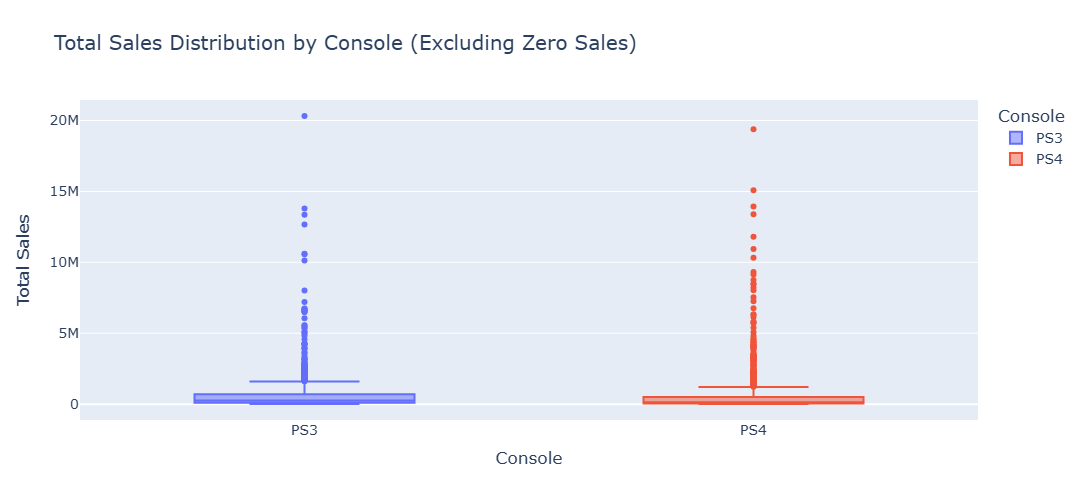

In [11]:
# Filter out zero sales for a cleaner distribution view
df_nonzero = df[df["Total Sales"] > 0]

# Boc plots in plotly: https://www.geeksforgeeks.org/python/box-plot-using-plotly-in-python/
fig = px.box(df_nonzero, x="Console", y="Total Sales", color="Console",
             title="Total Sales Distribution by Console (Excluding Zero Sales)",
             width=1000, height=500)
fig.update_layout(font_size=14)
fig.show()

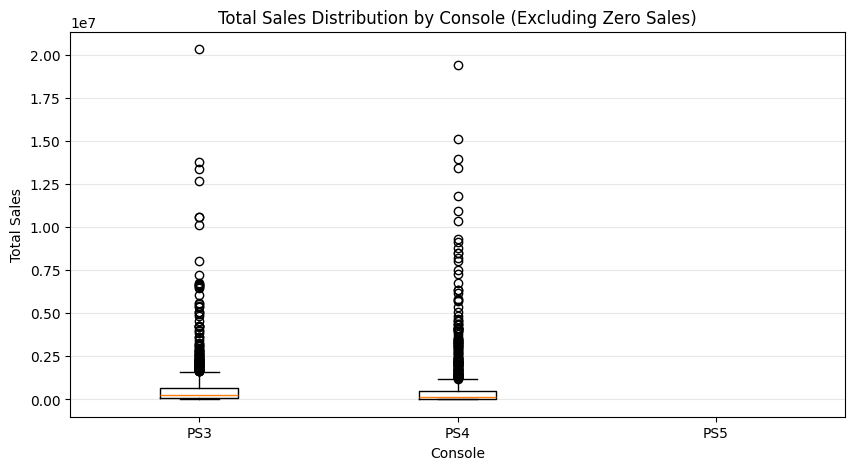

In [59]:
# Excluding zero sales for cleaner comparison
df_nonzero = df[df['Total Sales'] > 0]

ps3_sales = df_nonzero[df_nonzero['Console'] == 'PS3']['Total Sales']
ps4_sales = df_nonzero[df_nonzero['Console'] == 'PS4']['Total Sales']
ps5_sales = df_nonzero[df_nonzero['Console'] == 'PS5']['Total Sales']

plt.figure(figsize=(10, 5))
plt.boxplot([ps3_sales, ps4_sales, ps5_sales], tick_labels=['PS3', 'PS4', 'PS5'])
plt.title('Total Sales Distribution by Console (Excluding Zero Sales)')
plt.xlabel('Console')
plt.ylabel('Total Sales')
plt.grid(axis='y', alpha=0.3)
plt.show()

#### 3.2.5 Number of Games per Console

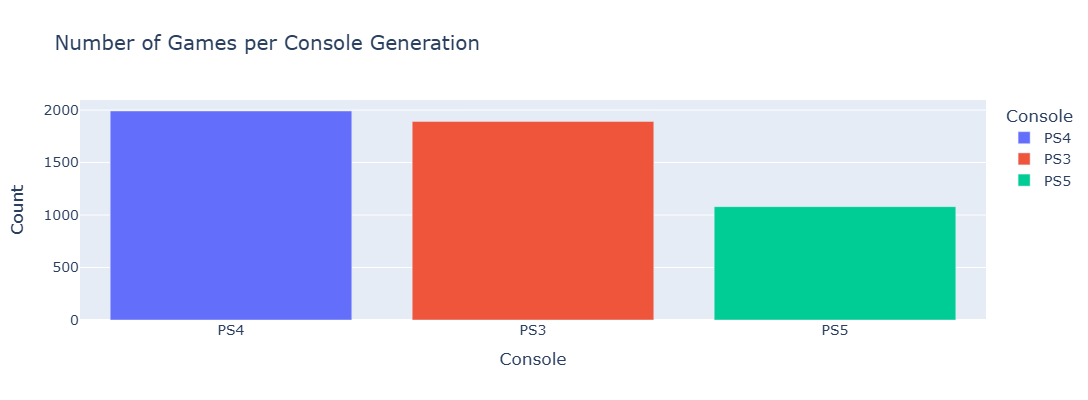

In [12]:
console_counts = df["Console"].value_counts().reset_index()
console_counts.columns = ["Console", "Count"]

fig = px.bar(console_counts, x="Console", y="Count", color="Console",
             title="Number of Games per Console Generation",
             width=800, height=400)
fig.update_layout(font_size=14)
fig.show()

### 3.2 Regional Sales Analysis

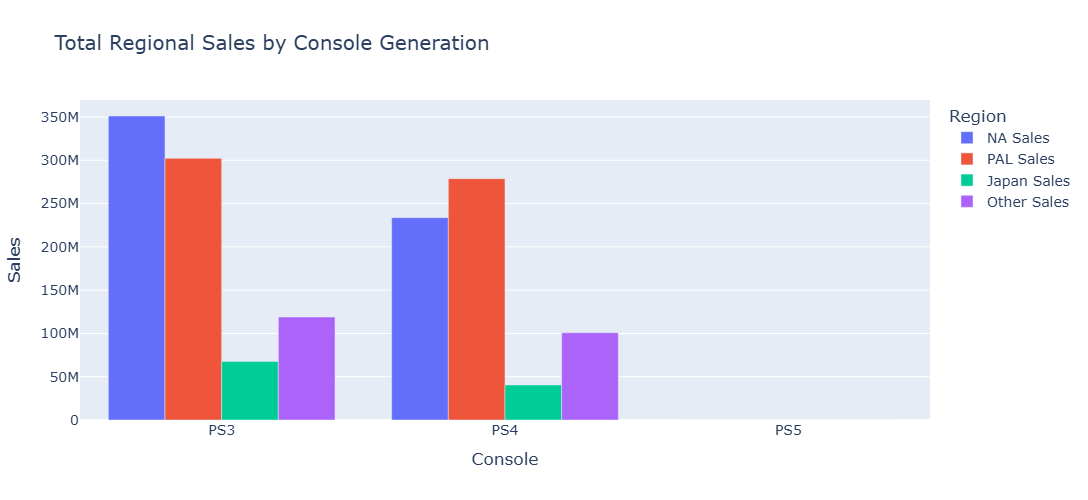

In [13]:
# Total regional sales by console
regional = df.groupby("Console")[["NA Sales", "PAL Sales", "Japan Sales", "Other Sales"]].sum().reset_index()
regional_melted = regional.melt(id_vars="Console", var_name="Region", value_name="Sales")

fig = px.bar(regional_melted, x="Console", y="Sales", color="Region",
             barmode="group",
             title="Total Regional Sales by Console Generation",
             width=1000, height=500)
fig.update_layout(font_size=14)
fig.show()

### 3.3 Genre Analysis

#### 3.3.1 Top Genres by game count

In [18]:
# NEW DATAFRAME - Extracting 'primary genre'
df["Primary Genre"] = df["genres"].str.split(',').str[0].str.strip()

print("Number of unique genres:", df["Primary Genre"].nunique())
print("\nTop 10 genres by game count:")
df["Primary Genre"].value_counts().head(10)

Number of unique genres: 19

Top 10 genres by game count:


Primary Genre
Adventure     529
Action        415
Shooter       346
Indie         301
Arcade        217
Racing        183
Sports        156
Strategy      149
Casual        146
Platformer     99
Name: count, dtype: int64

#### 3.3.2 Top Genres by Total Sales

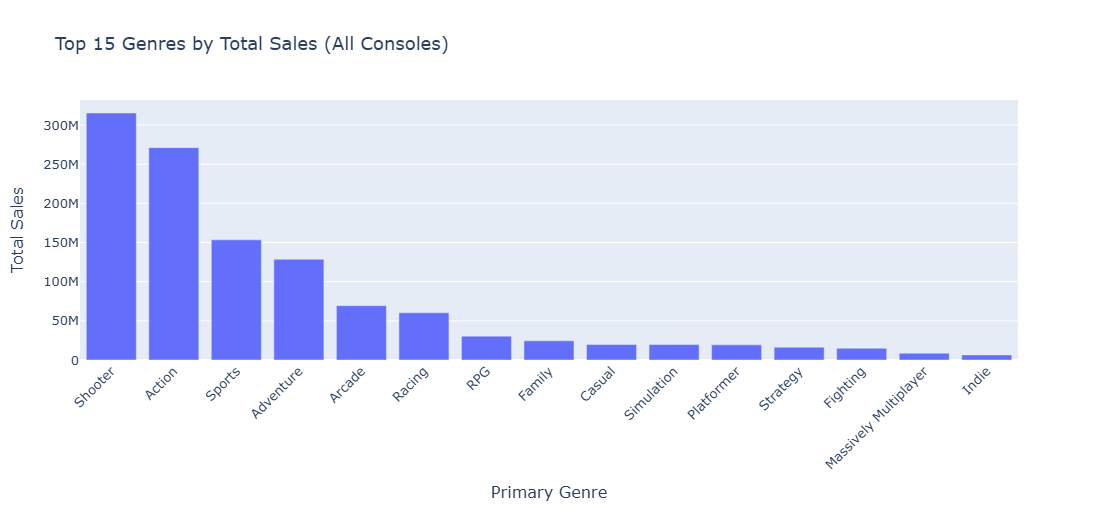

In [20]:
genre_sales = df.groupby("Primary Genre")["Total Sales"].sum().reset_index()
genre_sales = genre_sales.sort_values("Total Sales", ascending=False).head(15)

fig = px.bar(genre_sales, x="Primary Genre", y="Total Sales",
             title="Top 15 Genres by Total Sales (All Consoles)",
             width=1100, height=500)
fig.update_layout(font_size=13, xaxis_tickangle=-45)
fig.show()

#### 3.3.3 Top Genre Sales by Console Generation

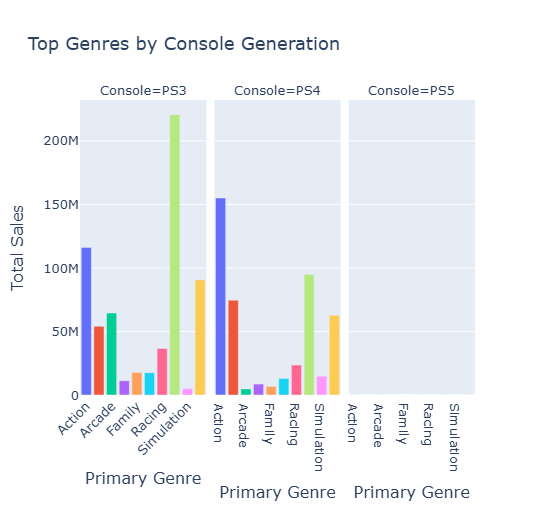

In [58]:

# Finding top 10 genres overall based on total sales
top_genres = df.groupby("Primary Genre")["Total Sales"].sum().nlargest(10).index

top_genres = (
    df.groupby("Primary Genre")["Total Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

genre_console_filtered = genre_console[
    genre_console["Primary Genre"].isin(top_genres)
]

fig = px.bar(
    genre_console_filtered,
    x="Primary Genre",
    y="Total Sales",
    color="Primary Genre",
    facet_col="Console",
    title="Top Genres by Console Generation",
    width=1200,
    height=500
)
fig.update_layout(font_size=13, xaxis_tickangle=-45, showlegend=False)
fig.show()

### 3.4 Correlation Analysis

#### 3.4.1 Correlation Matrix

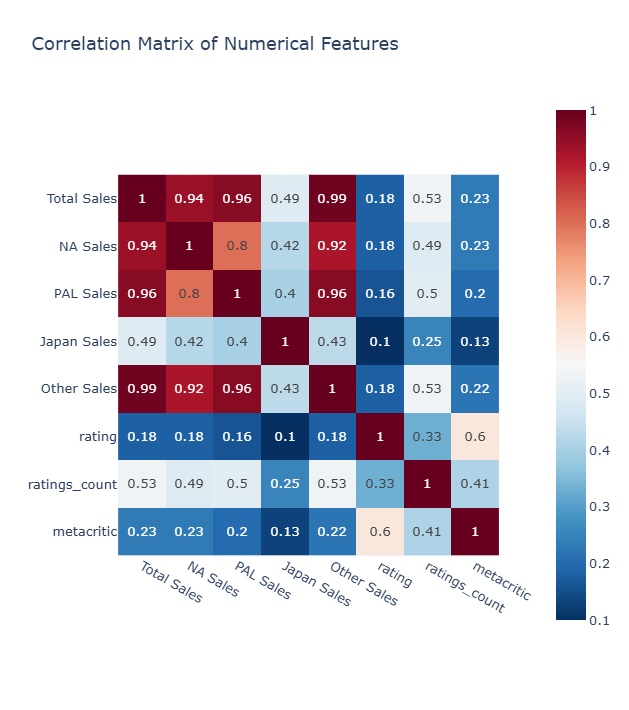

In [22]:
# Correlation matrix: https://github.com/zhiwu-huang/AICE1006-Data-Analytics-EDA/blob/main/10_correlation/10_slides_correlation.ipynb
num_cols = ["Total Sales", "NA Sales", "PAL Sales", "Japan Sales", 
            "Other Sales", "rating", "ratings_count", "metacritic"]

corr_matrix = df[num_cols].corr().round(2) # https://databasecamp.de/en/ml/correlation-matrix, https://plotly.com/python/heatmaps/

fig = px.imshow(corr_matrix, text_auto=True, 
                color_continuous_scale="RdBu_r",
                title='Correlation Matrix of Numerical Features',
                width=800, height=700)
fig.update_layout(font_size=13)
fig.show()

#### 3.4.2 Sales vs Rating

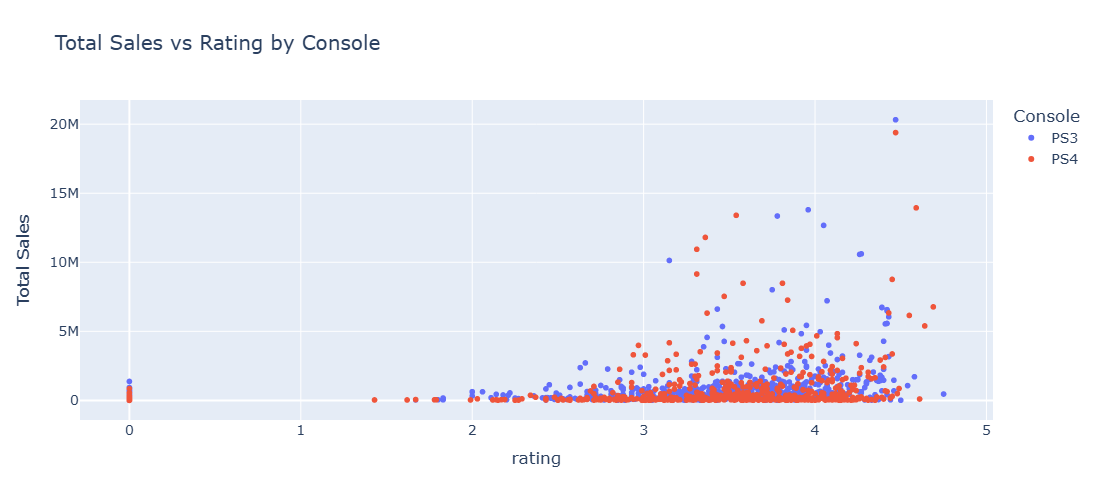

In [23]:
df_nonzero = df[df["Total Sales"] > 0]

fig = px.scatter(df_nonzero, x="rating", y="Total Sales", color="Console",
                 hover_data=["Name"],
                 title="Total Sales vs Rating by Console",
                 width=1000, height=500)
fig.update_layout(font_size=14)
fig.show()

I then looked more directly at the relationship between `rating` and `Total Sales` using a scatter plot broken down by console. This was intended to show whether higher-rated games tended to sell better, and whether this relationship looked consistent across platforms. To verify this, I implemented the scatter plot below. The scatter plot suggests that higher user ratings are only weakly associated with higher total sales, as most games remain clustered at relatively low sales levels across almost the full rating range. This indicates that user rating alone is not a strong predictor of commercial success, although some of the highest-selling outliers do still appear among more highly rated titles.

#### 3.4.3 Sales vs Metacritic Score

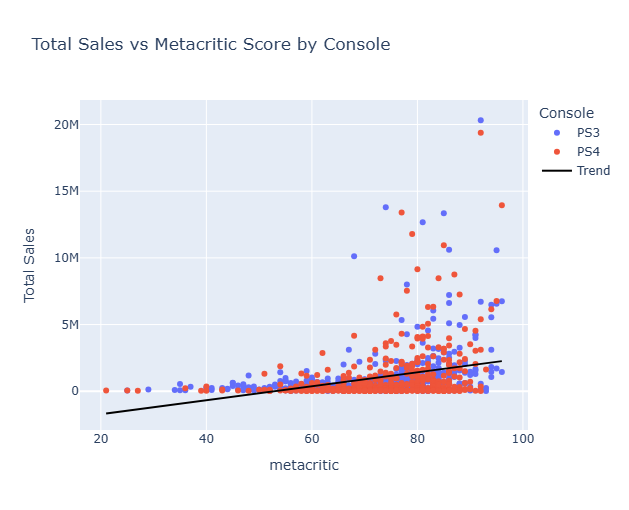

In [25]:
# Adding trendline: https://plotly.com/python/linear-fits/

# NEW DATAFRAME - for 'metacritic' and 'Total sales' values > 0
df_meta = df[(df["metacritic"] > 0) & (df["Total Sales"] > 0)]

# Fitting the trendline
z = np.polyfit(df_meta["metacritic"], df_meta["Total Sales"], 1)
p = np.poly1d(z)
x_line = np.linspace(df_meta["metacritic"].min(), df_meta["metacritic"].max(), 100)

fig = px.scatter(
    df_meta,
    x="metacritic",
    y="Total Sales",
    color="Console",
    hover_data=["Name"],
    title="Total Sales vs Metacritic Score by Console",
    width=1000,
    height=500
)

# Add trendline manually
fig.add_scatter(
    x=x_line,
    y=p(x_line),
    mode="lines",
    name="Trend",
    line=dict(color="black", width=2)
)

fig.show()

### 3.5 Top Games, Publishers, and Developers

#### 3.5.1 Top Performing Games Analysis

In [26]:
top_games = df.nlargest(10, "Total Sales") # https://www.w3schools.com/python/pandas/ref_df_nlargest.asp

top_games[["Name", "Console", "Total Sales", "Primary Genre", "Publisher"]]

,Name,Console,Total Sales,Primary Genre,Publisher
0,Grand Theft Auto V,PS3,20320000,Action,Rockstar Games
1,Grand Theft Auto V,PS4,19390000,Action,Rockstar Games
2,Call of Duty: Black Ops 3,PS4,15090000,NaN,Activision
3,Red Dead Redemption 2,PS4,13940000,Action,Rockstar Games
4,Call of Duty: Black Ops II,PS3,13800000,Shooter,Activision
5,Call of Duty: WWII,PS4,13400000,Shooter,Activision
6,Call of Duty: Modern Warfare 3,PS3,13350000,Shooter,Activision
7,Call of Duty: Black Ops,PS3,12670000,Shooter,Activision
8,FIFA 18,PS4,11800000,Sports,EA Sports
9,FIFA 17,PS4,10940000,Sports,Electronic Arts


#### 3.5.2 Top Selling Games across any console

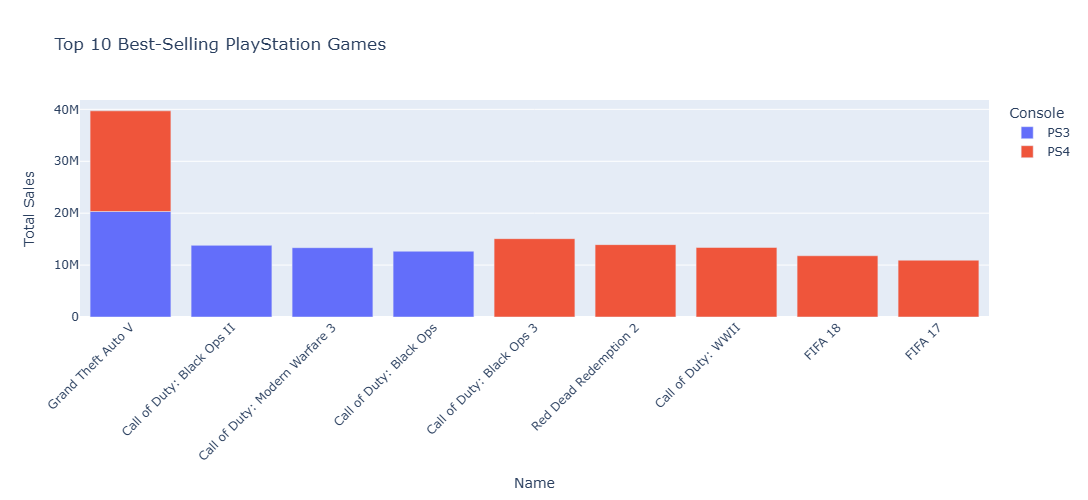

In [27]:
fig = px.bar(top_games, x="Name", y="Total Sales", color="Console",
             title="Top 10 Best-Selling PlayStation Games",
             width=1000, height=500)

fig.update_layout(xaxis_tickangle=-45)
fig.show()

#### 3.5.3 Top Publishers by Total Sales

In [28]:
publisher_sales = df.groupby("Publisher")["Total Sales"].sum().reset_index()
publisher_sales = publisher_sales.sort_values("Total Sales", ascending=False).head(10)

publisher_sales

,Publisher,Total Sales
17,Activision,205940000
138,Electronic Arts,153760000
130,EA Sports,129990000
447,Ubisoft,128370000
382,Sony Computer Entertainment,103700000
355,Rockstar Games,82280000
394,Square Enix,58150000
385,Sony Interactive Entertainment,57870000
58,Bethesda Softworks,53740000
469,Warner Bros. Interactive Entertainment,51850000


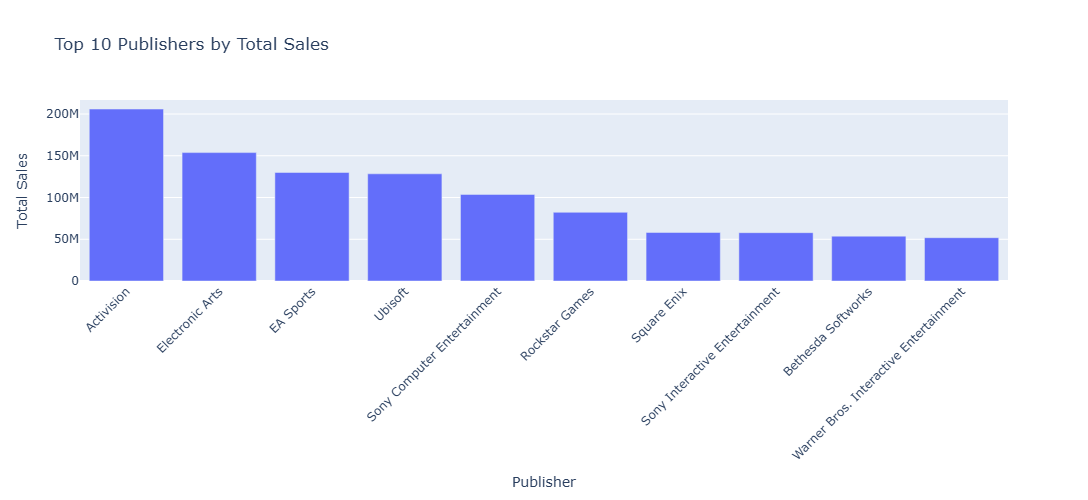

In [29]:
fig = px.bar(publisher_sales, x="Publisher", y="Total Sales",
             title="Top 10 Publishers by Total Sales",
             width=1000, height=500)

fig.update_layout(xaxis_tickangle=-45)
fig.show()

#### 3.5.4 Top Developers by Total Sales

In [30]:
dev_sales = df.groupby("Developer")["Total Sales"].sum().reset_index()
dev_sales = dev_sales.sort_values("Total Sales", ascending=False).head(10)

dev_sales

,Developer,Total Sales
350,EA Canada,90580000
1411,Ubisoft Montreal,70260000
1388,Treyarch,61580000
608,Infinity Ward,54150000
1069,Rockstar North,52370000
360,EA Tiburon,44720000
1454,Visual Concepts,35670000
352,EA DICE,32650000
845,Naughty Dog,32110000
209,Capcom,31960000


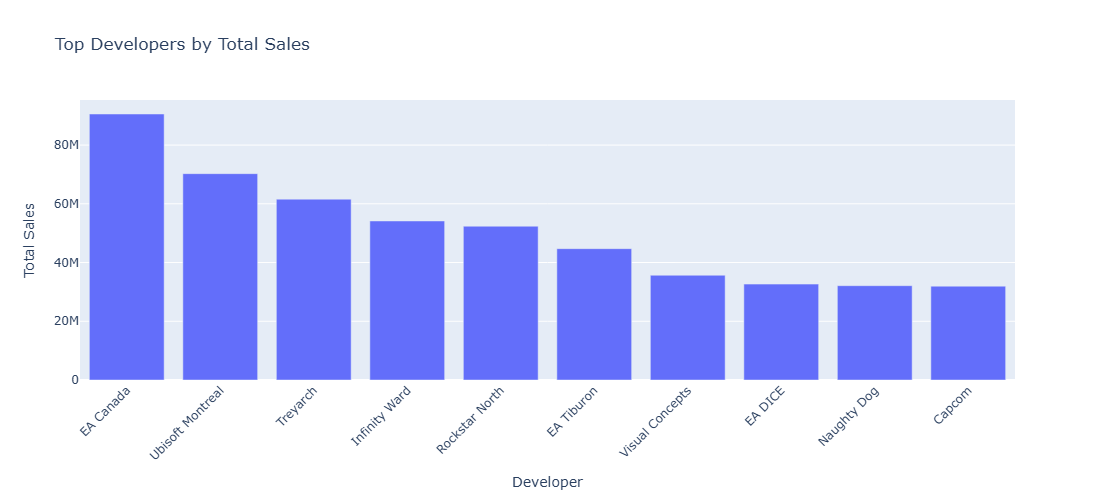

In [31]:
fig = px.bar(dev_sales, x="Developer", y="Total Sales",
             title="Top Developers by Total Sales",
             width=1000, height=500)

fig.update_layout(xaxis_tickangle=-45)
fig.show()

Finally, I examined the top developers by total sales. This provided a similar perspective at development-studio level and helped identify whether strong sales performance appeared to be associated with particular development teams as well as publishing companies. These developer-level results show that **EA Canada** leads the total sales, followed by **Ubisoft Montreal** and **Treyarch**, with **Infinity Ward** and **Rockstar North** also contributing strongly. This suggests that high-selling PlayStation games are concentrated among a relatively small number of major studios, many of which are closely associated with successful long-running franchises (e.g. FIFA).

## 4. Feature Engineering

### 4.1 Regional Sales Share

In [33]:
# NEW DATAFRAMES - for each Regions' Sales Share
df["NA_Sales_Share"] = (df["NA Sales"] / df["Total Sales"] * 100).round(2)
df["PAL_Sales_Share"] = (df["PAL Sales"] / df["Total Sales"] * 100).round(2)
df["Japan_Sales_Share"] = (df["Japan Sales"] / df["Total Sales"] * 100).round(2)

df[["Name", "Console", "Total Sales", "NA_Sales_Share", "PAL_Sales_Share", "Japan_Sales_Share"]].head(10)

,Name,Console,Total Sales,NA_Sales_Share,PAL_Sales_Share,Japan_Sales_Share
0,Grand Theft Auto V,PS3,20320000,31.35,48.47,4.87
1,Grand Theft Auto V,PS4,19390000,31.25,50.08,3.09
2,Call of Duty: Black Ops 3,PS4,15090000,40.95,40.09,2.72
3,Red Dead Redemption 2,PS4,13940000,37.73,44.55,1.51
4,Call of Duty: Black Ops II,PS3,13800000,36.16,42.61,4.71
5,Call of Duty: WWII,PS4,13400000,34.85,46.34,2.99
6,Call of Duty: Modern Warfare 3,PS3,13350000,41.50,43.30,3.67
7,Call of Duty: Black Ops,PS3,12670000,47.43,34.73,3.79
8,FIFA 18,PS4,11800000,10.76,73.22,1.27
9,FIFA 17,PS4,10940000,11.52,72.67,1.10


### 4.2 Regional sales share as percentage

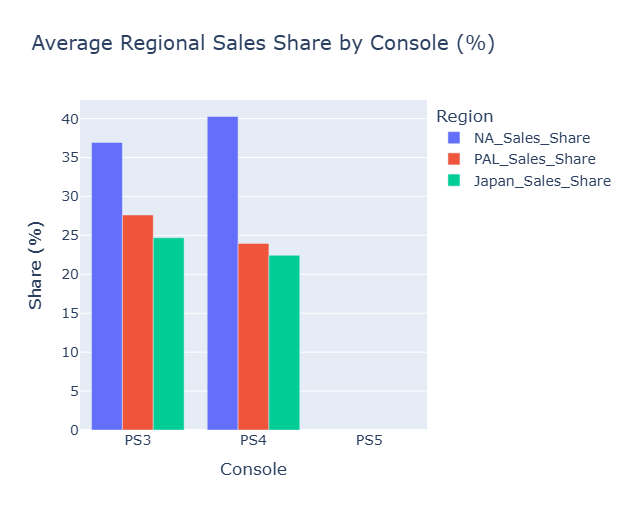

In [35]:
regional_share = df.groupby("Console")[["NA_Sales_Share", "PAL_Sales_Share", "Japan_Sales_Share"]].mean().round(2).reset_index()

# .melt - https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.melt.html
regional_share_melted = regional_share.melt(id_vars="Console", var_name="Region", value_name="Share (%)")

fig = px.bar(regional_share_melted, x="Console", y="Share (%)", color="Region",
             barmode="group",
             title="Average Regional Sales Share by Console (%)",
             width=1000, height=500)
fig.update_layout(font_size=14)
fig.show()

## 5. PCA

### 5.1 Preparing Data for PCA

In [55]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Keep only PS3 and PS4 data for PCA
df_pca = df[df["Console"].isin(["PS3", "PS4"])].copy()

# Selecting numerical sales features
pca_features = ["Total Sales", "NA Sales", "PAL Sales", "Japan Sales", "Other Sales"]
X = df_pca[pca_features].dropna()

# Standardising features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# BOTH RESULTS SHOULD BE THE SAME
## For the DataFrame before scaling
print("X shape:", X.shape)

## For the NumPy array after scaling
print("X_scaled shape:", X_scaled.shape)

X shape: (3883, 5)
X_scaled shape: (3883, 5)


### 5.2 Applying PCA

In [56]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# https://stackoverflow.com/questions/55678708/interpretation-of-pca-explained-variance-ratio
explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio:", explained_variance)
print("Cumulative explained variance:", explained_variance.cumsum())

Explained variance ratio: [8.03772126e-01 1.53090307e-01 4.10753068e-02 2.06050337e-03
 1.75657863e-06]
Cumulative explained variance: [0.80377213 0.95686243 0.99793774 0.99999824 1.        ]


### 5.3 Visualising the First Two Principal Components

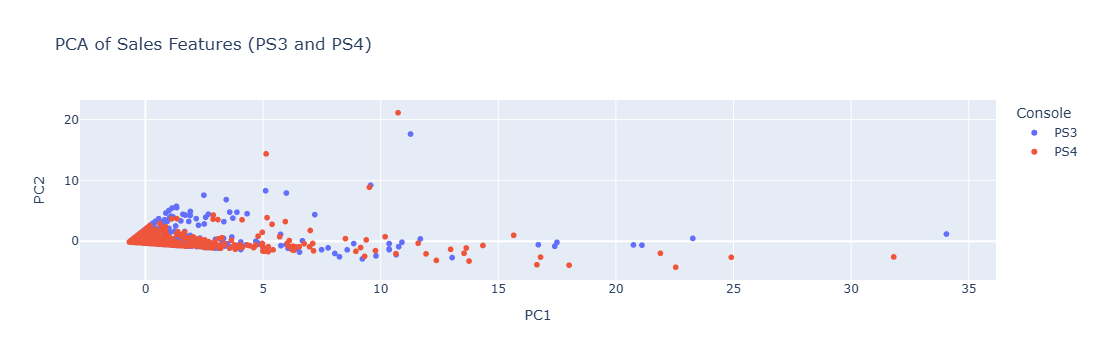

In [41]:
pca_df = pd.DataFrame(X_pca[:, :2], columns=["PC1", "PC2"], index=X.index)
pca_df["Console"] = df_pca.loc[X.index, "Console"].values

fig = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color="Console",
    title="PCA of Sales Features (PS3 and PS4)"
)
fig.show()

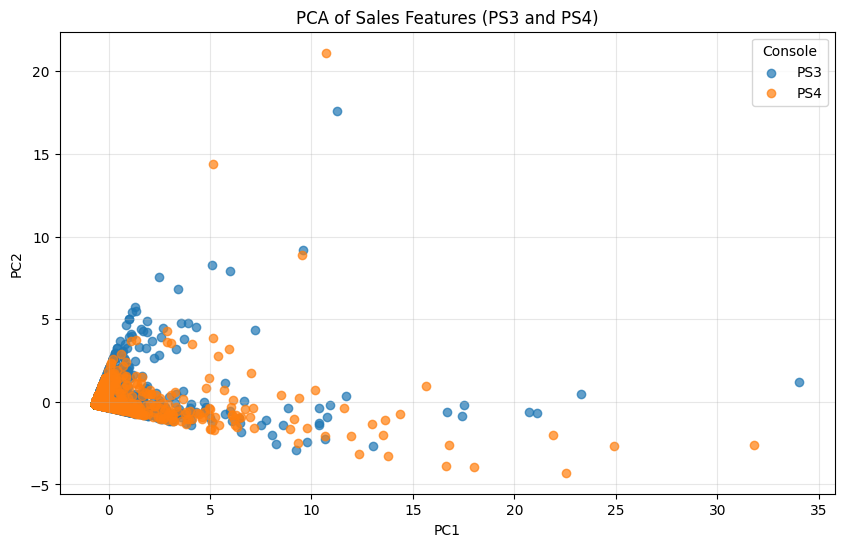

In [42]:
plt.figure(figsize=(10, 6))

for console in pca_df["Console"].unique():
    subset = pca_df[pca_df["Console"] == console]
    plt.scatter(subset["PC1"], subset["PC2"], label=console, alpha=0.7)

plt.title("PCA of Sales Features (PS3 and PS4)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Console")
plt.grid(alpha=0.3)
plt.show()

### 5.4 PCA Loadings Interpretation

In [43]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca_features))],
    index=pca_features
)

print(loadings[["PC1", "PC2"]])

                  PC1       PC2
Total Sales  0.497481 -0.080390
NA Sales     0.464683 -0.126621
PAL Sales    0.470564 -0.173802
Japan Sales  0.270749  0.959854
Other Sales  0.491779 -0.161177


## 6. Clustering

### 6.1 Preparing Data for Clustering

In [45]:
from sklearn.cluster import KMeans

# Reuse the PCA-ready data
# The values: 'df_pca', 'X', 'X_scaled' were already created in section 5
print("Clustering data shape:", X_scaled.shape)

Clustering data shape: (3883, 5)


### 6.2 Choosing the Number of Clusters

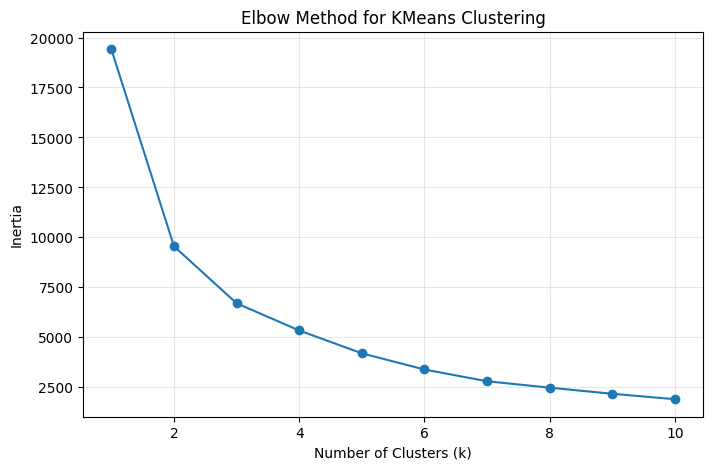

In [47]:
# https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/
# https://github.com/zhiwu-huang/AICE1006-Data-Analytics-EDA/blob/main/12_clustering/12_slides_clustering.ipynb
inertias = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Method for KMeans Clustering")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)
plt.show()

### 6.3 Applying KMeans Clustering

In [52]:
# https://medium.com/@jackiee.jecksom/clustering-and-principal-component-analysis-pca-from-sklearn-c8ea5fed6648
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

cluster_df = df_pca.loc[X.index].copy()
cluster_df["Cluster"] = clusters

cluster_df["Cluster"].value_counts().sort_index()

Cluster
0    3672
1     185
2      26
Name: count, dtype: int64

### 6.4 Visualising Clusters in PCA Space

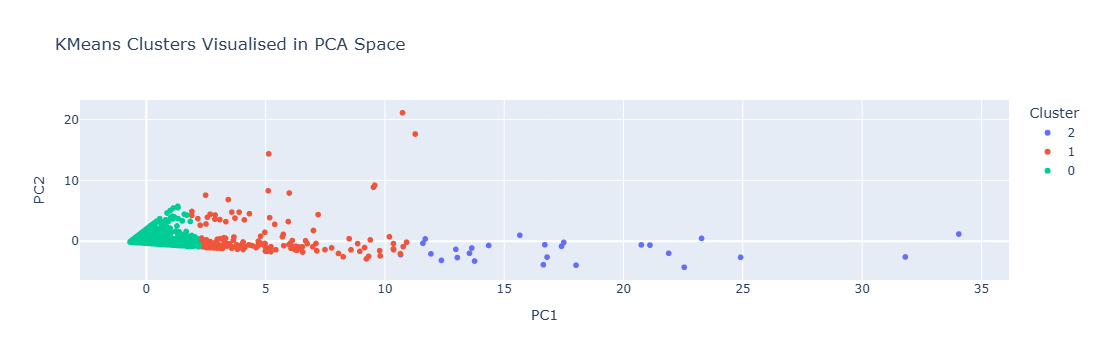

In [49]:
cluster_plot_df = pca_df.copy()
cluster_plot_df["Cluster"] = clusters

fig = px.scatter(
    cluster_plot_df,
    x="PC1",
    y="PC2",
    color=cluster_plot_df["Cluster"].astype(str),
    title="KMeans Clusters Visualised in PCA Space",
    labels={"color": "Cluster"}
)
fig.show()

In [51]:
cluster_summary = cluster_df.groupby("Cluster")[pca_features].mean().round(2)
cluster_summary

,Total Sales,NA Sales,PAL Sales,Japan Sales,Other Sales
Cluster,,,,,
0,174340.96,72344.77,59417.21,18235.29,24381.81
1,3079459.46,1212324.32,1227189.19,175945.95,463675.68
2,10901538.46,3646538.46,5219230.77,331538.46,1706153.85
